In [1]:
import matplotlib.pyplot as plt

from Observer_Manager import ObserverManager
from BEMT_Acoustic_Job import Job

In [2]:
"""DEFINE OBSERVER OBJECTS"""
r_observer = [[1.8, 0, 0],
              [0, 1.8, 0],
              [0, 0, 1.8]]
observer_manager = ObserverManager.from_positions(r_observer)

In [13]:
"""CREATE ANALYSIS OBJECT"""
propeller_name = "10x7E"
RPM = 6000
v_inf = 0 
revolutions = 6 #revolutions to simulate

analysis = Job(propeller_name=propeller_name, RPM=RPM, v_inf=v_inf, revolutions=revolutions, observer_manager=observer_manager)

In [14]:
"""RUN BEMT"""
analysis.run_BEMT()

Running BEMT for propeller 10X7E...


In [15]:
"""VIEW BEMT SOLUTION DATA"""
analysis.bemt_analysis.solution_data

,radius,chord,twist,phi,alpha,Cl,Cd,a,a_prime,dT,dQ,F,V,Re
0,0.027940,0.022291,45.3524,14.227867,31.124533,0.836129,0.956037,-6.003426e+04,0.224760,0.006445,0.000206,0.878762,13.609506,20531.949744
1,0.029464,0.022967,43.8433,13.896388,29.946912,0.834584,0.904292,-6.313322e+04,0.211404,0.007627,0.000243,0.897498,14.599095,22692.464318
2,0.030988,0.023520,42.4018,13.563699,28.838101,0.831323,0.855085,-5.067941e+04,0.198818,0.008883,0.000283,0.912892,15.599282,24831.721151
3,0.032512,0.023983,41.0356,13.237182,27.798418,0.826809,0.808562,-7.680331e+04,0.187021,0.010210,0.000325,0.925633,16.607445,26956.162175
4,0.034036,0.024402,39.7404,12.928568,26.811832,0.821404,0.764219,-5.174163e+04,0.175991,0.011620,0.000368,0.936158,17.621811,29102.451114
5,0.035560,0.024778,38.5119,12.638834,25.873066,0.815868,0.721789,-4.365795e+04,0.165544,0.013119,0.000413,0.944901,18.644257,31265.370704
6,0.037084,0.025113,37.3462,12.372262,24.973938,0.811162,0.680936,-4.655332e+04,0.155508,0.022136,0.000689,0.952156,19.677129,33443.944846
7,0.039375,0.025540,35.7042,12.030020,23.674180,0.808532,0.621765,7.334463e+04,0.140802,0.034693,0.001050,0.960708,21.256638,36742.429728
8,0.042410,0.025971,33.7122,11.744372,21.967828,0.823191,0.546819,1.253669e+05,0.121342,0.043689,0.001231,0.968268,23.413813,41155.387299
9,0.045453,0.026259,31.9044,11.689454,20.214946,0.868302,0.482895,4.877633e+05,0.103190,0.055798,0.001410,0.972428,25.612129,45516.980456


In [16]:
"""RUN ACOUSTIC ANALYSIS"""
analysis.run_acoustic_analysis()

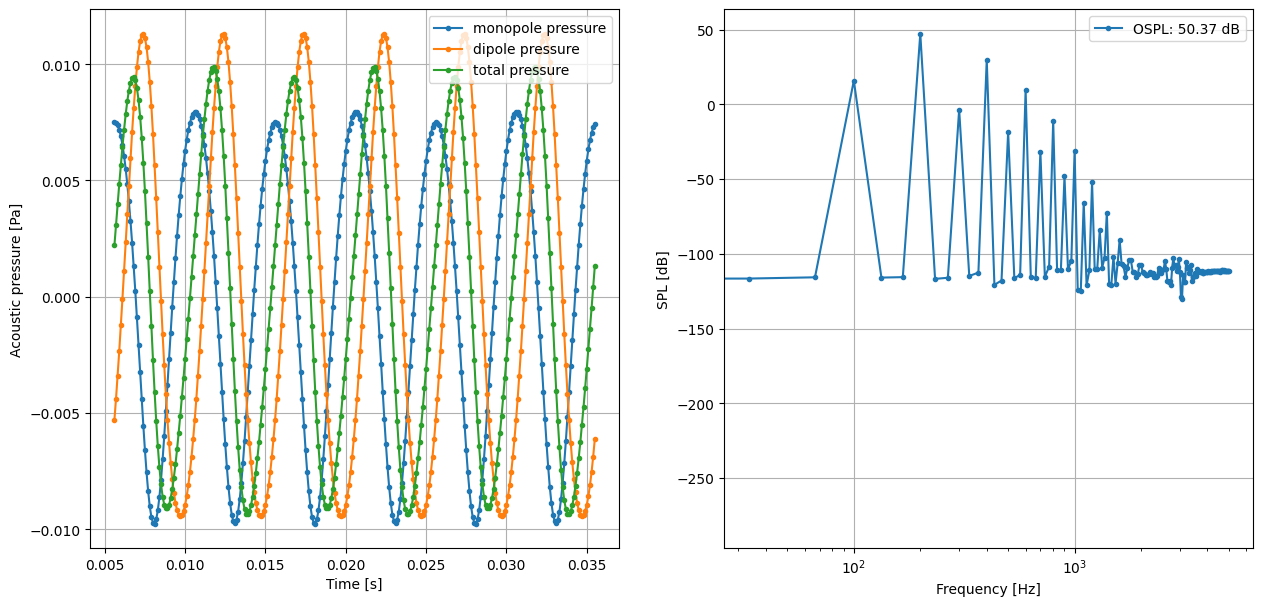

In [17]:
"""VIEW ACOUSTIC SOLUTION DATA"""
observer = analysis.observer_manager[1]

%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(7)
fig.set_figwidth(15)
fontsize=10
labelsize=10

axs[0].plot(observer.t, observer.p_m, marker='.', label='monopole pressure')
axs[0].plot(observer.t, observer.p_d, marker='.', label='dipole pressure')
axs[0].plot(observer.t, observer.p_m+observer.p_d, marker='.', label='total pressure')
axs[0].set_xlabel('Time [s]', fontsize=fontsize)
axs[0].set_ylabel('Acoustic pressure [Pa]', fontsize=fontsize)
axs[0].grid(True)
axs[0].legend()

axs[1].semilogx(observer.frequency, observer.SPL, marker='.', label=f'OSPL: {observer.OSPL:.2f} dB')
axs[1].set_xlabel('Frequency [Hz]', fontsize=fontsize)
axs[1].set_ylabel('SPL [dB]', fontsize=fontsize)
axs[1].grid(True)
axs[1].legend()